<a href="https://colab.research.google.com/github/HinaH1/dental-caries-segmentation/blob/main/experiments/02_segmentation_detection_initial_trial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 2: Dataset Quality and Scale Assessment

## Objective

To evaluate the suitability of the selected dataset for training a robust deep learning model for dental caries detection.

This assessment focused on:

- Dataset size
- Image quality
- Annotation reliability
- Clinical realism

---

## Initial Observations

Upon inspection of the dataset, several limitations were identified:

- Limited number of training images
- Low image resolution and inconsistent contrast
- Variability in annotation precision
- Reduced clarity of carious lesions in several samples

---

## Technical Concerns

Deep learning models, particularly convolutional neural networks, require:

- Sufficient data volume for generalisation
- Consistent image quality
- Clear lesion representation

A small dataset increases the risk of:

- Overfitting
- Poor generalisation to unseen data
- Inflated evaluation metrics

---

## Dataset Scale Analysis

The dataset was analysed to determine:

- Total number of images
- Number of labelled samples
- Class distribution balance

The dataset size was deemed insufficient for training a clinically robust segmentation model.

---

## Decision

Due to limitations in dataset scale and quality, this dataset was not selected as the primary training dataset.

A larger and higher-quality dataset was sourced to improve model robustness and research validity.

---

## Conclusion

This experiment highlighted the importance of dataset scale and image clarity in medical image segmentation tasks.

Dataset selection was revised to ensure:

- Improved generalisation potential
- Better lesion visibility
- Stronger experimental validity

In [2]:
!ls

sample_data


In [3]:
!unzip "zentia_periapicaldataset_cariesonly.coco.zip"

unzip:  cannot find or open zentia_periapicaldataset_cariesonly.coco.zip, zentia_periapicaldataset_cariesonly.coco.zip.zip or zentia_periapicaldataset_cariesonly.coco.zip.ZIP.


In [4]:
!unzip "zentia_periapicaldataset_cariesonly.coco.zip" -d seg_data

unzip:  cannot find or open zentia_periapicaldataset_cariesonly.coco.zip, zentia_periapicaldataset_cariesonly.coco.zip.zip or zentia_periapicaldataset_cariesonly.coco.zip.ZIP.


In [5]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="gKXgpQfXZcLo2AjGBatg")
project = rf.workspace("hinas-workspace").project("zentia_periapicaldataset_cariesonly-cbxbu-ghjus")
version = project.version(2)
dataset = version.download("png-mask-semantic")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 76.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to zentia_periapicaldataset_cariesonly-2 in png-mask-semantic:: 100%|██████████| 594/594 [00:00<00:00, 3418.08it/s]


In [1]:
!ls


sample_data  zentia_periapicaldataset_cariesonly-2  zentia_yolo_seg


In [2]:
!find zentia_periapicaldataset_cariesonly-2 -maxdepth 3 -type d

zentia_periapicaldataset_cariesonly-2
zentia_periapicaldataset_cariesonly-2/test
zentia_periapicaldataset_cariesonly-2/train
zentia_periapicaldataset_cariesonly-2/valid


In [3]:
!find zentia_periapicaldataset_cariesonly-2/train -maxdepth 2 -type d -print
!find zentia_periapicaldataset_cariesonly-2/valid -maxdepth 2 -type d -print
!find zentia_periapicaldataset_cariesonly-2/test  -maxdepth 2 -type d -print

zentia_periapicaldataset_cariesonly-2/train
zentia_periapicaldataset_cariesonly-2/valid
zentia_periapicaldataset_cariesonly-2/test


In [4]:
!find zentia_periapicaldataset_cariesonly-2/train -maxdepth 2 -type f | head -n 20

zentia_periapicaldataset_cariesonly-2/train/207_jpg.rf.614e3ec8f2f714f4c4f75f7476444407_mask.png
zentia_periapicaldataset_cariesonly-2/train/361_jpg.rf.dab78d2280b58a92d32d174db2cd1a46_mask.png
zentia_periapicaldataset_cariesonly-2/train/778_jpg.rf.6c034e06d4fb08c4c6cea683184bcb9e.jpg
zentia_periapicaldataset_cariesonly-2/train/405_jpg.rf.44517831da4c091b70a72208d854e244.jpg
zentia_periapicaldataset_cariesonly-2/train/1346_jpg.rf.b657f2592cecd02a60cbeea37eee74f5_mask.png
zentia_periapicaldataset_cariesonly-2/train/387_jpg.rf.d3831ba369380d4d596d08ec06d4112f_mask.png
zentia_periapicaldataset_cariesonly-2/train/540_jpg.rf.326c44b6d4e9f659582d2fe89e356696_mask.png
zentia_periapicaldataset_cariesonly-2/train/634_jpg.rf.9d92376faaa767a931538eda52fb4cd1_mask.png
zentia_periapicaldataset_cariesonly-2/train/946_jpg.rf.610c5e5a7c1ecf49f25a1835eb180eef_mask.png
zentia_periapicaldataset_cariesonly-2/train/271_jpg.rf.a66ef06d1d30cf9f11281e0b73faec57_mask.png
zentia_periapicaldataset_cariesonly-2/t

In [5]:
import shutil
from pathlib import Path
import cv2
import numpy as np

DATA_DIR = Path("/content/zentia_periapicaldataset_cariesonly-2")
OUT = Path("/content/zentia_yolo_seg")

if OUT.exists():
    shutil.rmtree(OUT)
OUT.mkdir(parents=True, exist_ok=True)

def mask_to_polygons(mask_img):
    bin_mask = (mask_img > 0).astype(np.uint8) * 255
    if bin_mask.max() == 0:
        return []
    contours, _ = cv2.findContours(bin_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polys = []
    for cnt in contours:
        if len(cnt) < 3:
            continue
        approx = cv2.approxPolyDP(cnt, 1.0, True)
        if len(approx) < 3:
            continue
        polys.append(approx.reshape(-1, 2).astype(np.float32))
    return polys

def write_yolo_seg_label(polys, w, h, label_path, cls_id=0):
    lines = []
    for poly in polys:
        pts = []
        for x, y in poly:
            xn = min(max(float(x)/w, 0.0), 1.0)
            yn = min(max(float(y)/h, 0.0), 1.0)
            pts.extend([f"{xn:.6f}", f"{yn:.6f}"])
        if len(pts) >= 6:
            lines.append(f"{cls_id} " + " ".join(pts))
    if lines:
        label_path.write_text("\n".join(lines) + "\n")
        return True
    return False

def convert_split(split, out_split):
    split_dir = DATA_DIR / split

    imgs = list(split_dir.glob("*.jpg")) + list(split_dir.glob("*.png"))
    masks = list(split_dir.glob("*_mask.png"))  # <-- key

    # Build mask lookup by removing "_mask" from stem
    mask_map = {}
    for m in masks:
        key = m.stem.replace("_mask", "")  # mask stem without suffix
        mask_map[key] = m

    (OUT / out_split / "images").mkdir(parents=True, exist_ok=True)
    (OUT / out_split / "labels").mkdir(parents=True, exist_ok=True)

    kept = 0
    inst = 0

    for im in imgs:
        stem = im.stem
        m = mask_map.get(stem)
        if m is None:
            continue

        img = cv2.imread(str(im), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(str(m), cv2.IMREAD_GRAYSCALE)
        if img is None or mask is None:
            continue

        h, w = img.shape[:2]
        polys = mask_to_polygons(mask)
        if not polys:
            continue

        shutil.copy(im, OUT / out_split / "images" / im.name)
        ok = write_yolo_seg_label(polys, w, h, OUT / out_split / "labels" / f"{stem}.txt", cls_id=0)
        if ok:
            kept += 1
            inst += len(polys)

    print(f"{split}: images={len(imgs)}, masks={len(masks)}, kept={kept}, approx_instances={inst}")
    return kept

total = 0
total += convert_split("train", "train")
total += convert_split("valid", "valid")
total += convert_split("test", "test")

# Write data.yaml
yaml_text = f"""path: {OUT}
train: train/images
val: valid/images
test: test/images
names:
  0: caries
"""
(OUT / "data.yaml").write_text(yaml_text)

print("\n✅ Finished. Total kept images:", total)
print("YOLOv8-seg dataset at:", OUT)

train: images=468, masks=234, kept=234, approx_instances=332
valid: images=88, masks=44, kept=44, approx_instances=69
test: images=30, masks=15, kept=15, approx_instances=19

✅ Finished. Total kept images: 293
YOLOv8-seg dataset at: /content/zentia_yolo_seg


In [ ]:
!find /content/zentia_yolo_seg/train/labels -type f | head -n 5
!sed -n '1,2p' $(find /content/zentia_yolo_seg/train/labels -type f | head -n 1)

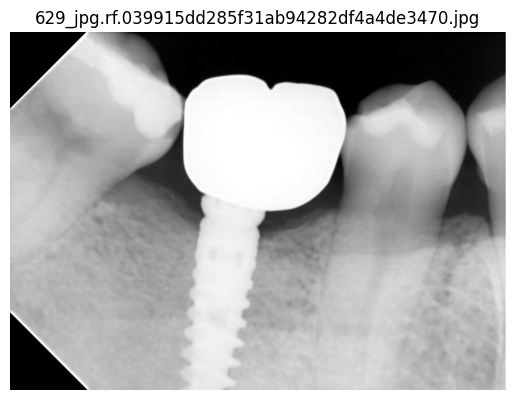

In [6]:
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
import random

img_dir = Path("/content/zentia_yolo_seg/train/images")
img_path = random.choice(list(img_dir.glob("*.jpg")))

img = cv2.imread(str(img_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(img_path.name)
plt.axis("off")
plt.show()

IMAGE FILE: 154_jpg.rf.5aa3d1f1624faa0817a52200cdcdc595.jpg
LABEL FILE: 154_jpg.rf.5aa3d1f1624faa0817a52200cdcdc595.txt
Full image path: /content/zentia_yolo_seg/train/images/154_jpg.rf.5aa3d1f1624faa0817a52200cdcdc595.jpg
Number of caries regions in this image: 1


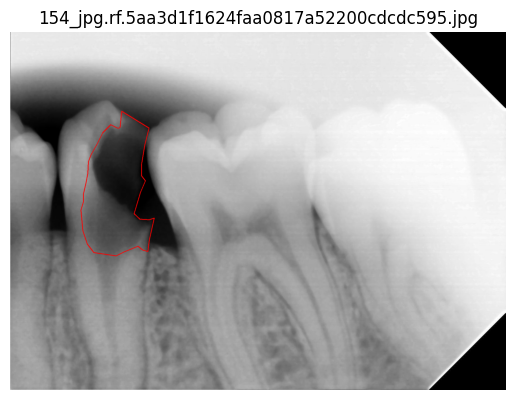

In [7]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pathlib import Path
import random

img_dir = Path("/content/zentia_yolo_seg/train/images")
label_dir = Path("/content/zentia_yolo_seg/train/labels")

# Pick random image
img_path = random.choice(list(img_dir.glob("*.jpg")))
label_path = label_dir / (img_path.stem + ".txt")

print("IMAGE FILE:", img_path.name)
print("LABEL FILE:", label_path.name)
print("Full image path:", img_path)

img = cv2.imread(str(img_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

if label_path.exists():
    with open(label_path) as f:
        lines = f.readlines()

    print("Number of caries regions in this image:", len(lines))

    for line in lines:
        parts = line.strip().split()
        coords = list(map(float, parts[1:]))

        pts = []
        for i in range(0, len(coords), 2):
            x = int(coords[i] * w)
            y = int(coords[i+1] * h)
            pts.append([x, y])

        pts = np.array(pts, np.int32)
        cv2.polylines(img, [pts], True, (255,0,0), 2)

plt.imshow(img)
plt.title(img_path.name)
plt.axis("off")
plt.show()

Image: 670_jpg.rf.d09641ae594ad8131cef72a06e6dae0f.jpg


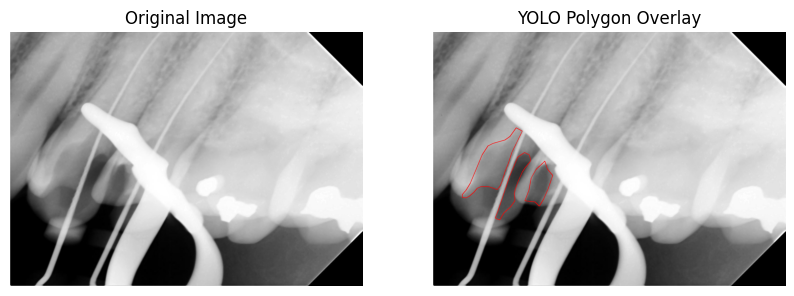

In [11]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pathlib import Path
import random

converted_dir = Path("/content/zentia_yolo_seg/train/images")
label_dir = Path("/content/zentia_yolo_seg/train/labels")
original_dir = Path("/content/zentia_periapicaldataset_cariesonly-2/train")

img_path = random.choice(list(converted_dir.glob("*.jpg")))
label_path = label_dir / (img_path.stem + ".txt")
original_path = original_dir / img_path.name

print("Image:", img_path.name)

# Load original
orig = cv2.imread(str(original_path))
orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

# Copy for overlay
overlay = orig.copy()
h, w = overlay.shape[:2]

if label_path.exists():
    with open(label_path) as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        coords = list(map(float, parts[1:]))

        pts = []
        for i in range(0, len(coords), 2):
            x = int(coords[i] * w)
            y = int(coords[i+1] * h)
            pts.append([x, y])

        pts = np.array(pts, np.int32)
        cv2.polylines(overlay, [pts], True, (255,0,0), 2)

# Show side by side
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(orig)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(overlay)
plt.title("YOLO Polygon Overlay")
plt.axis("off")

plt.show()




## Reflection

Model performance is highly dependent on dataset quality and scale.

Rather than proceeding with suboptimal data, the research direction was adjusted to prioritise:

- Larger datasets
- Clearer radiographic detail
- More reliable annotations

This decision strengthens the methodological integrity of the project.